In [2]:
import nibabel as nib
from pathlib import Path
from tqdm import tqdm
from matplotlib import pyplot as plt
from parse import parse
import numpy as np
import os 

RAW = Path("/depict/data/hedit/raw/")
DERIVATIVES = Path("/depict/data/hedit/derivatives/pipeline-bodydyn/")

In [ ]:
def get_ix_min_max(p):
    img = nib.load(p).get_fdata()
    ix_max = np.max(np.where((img==91).any(axis=(0,1))))
    ix_min = np.min(np.where((img==25).any(axis=(0,1))))

    return ix_min,ix_max
    #y = np.zeros((img.shape[-1],img.shape[2]))

data = {}
for sub in tqdm(list(DERIVATIVES.glob("**/*total*.nii.gz"))):
    sub_id = parse(str(DERIVATIVES)+"/{}/{}",str(sub))[0]
    data[sub_id] = get_ix_min_max(sub)

    

In [115]:
import glob

arr = np.zeros((99,69,1000))
for i, f in enumerate(glob.glob(f"/homes/hinge/Projects/hedypet-streamlit/axial_distribution_fdg/*.npy")):
    sub = os.path.basename(f).replace(".npy","")
    ix_min,ix_max = data[sub]
    arr2 = np.load(f)
    for ii in range(69):
        arr[i,ii,:] = np.interp(np.linspace(ix_min-100,ix_max,1000),np.arange(645),arr2[ii])

#arr = arr[:40,...]
arr/=arr.mean(axis=(1,2),keepdims=True)
arr3 = arr.mean(axis=0)


In [ ]:
arr2 = np.zeros((99,681,1000))
arr4 = np.zeros((4050,1000))
arr5 = np.zeros((99, 4050,1000))

t = [1,3,5,7,9,11.0,13.0,15.0,17.0,19.0,21.0,23.0,25.0,27.0,29.0,31.0,33.0,35.0,37.0,39.0,42.5,47.5,52.5,57.5,62.5,67.5,72.5,77.5,82.5,87.5,95.0,105,115,125,135,145,155,165,175,185,195,205,215,225,235,270,330,390,450,510,570,660,780,900,1020,1140,1260,1380,1500,1620,1740,1950,2250,2550,2850,3150,3450,3750,4050]

for i in range(99):
    for ii in range(1000):
        arr2[i,:,ii] = np.interp(np.linspace(0,68,681),np.arange(69),arr[i,:,ii])
        arr5[i,:,ii] = np.interp(np.arange(4050),t,arr[i,:,ii])
arr4 = arr5.mean(axis=0)
np.savez_compressed("dist.npy.gz",arr4)

(0.0, 1000.0)

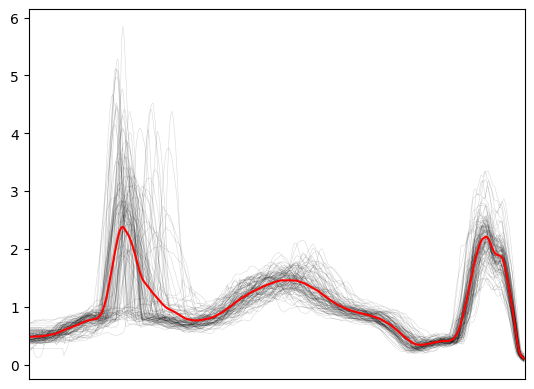

In [112]:
ix = 66
for i in range(arr.shape[0]):
    plt.plot(arr[i,ix,:],linewidth=0.4,color="black",alpha=0.15)

plt.plot(arr[:,ix,:].mean(axis=0),color="red",linewidth=1.5)
plt.xticks([])
plt.xlim([0,1000])

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import imageio
import io

# Load your 'arr' variable before running this script.
t = [1,3,5,7,9,11.0,13.0,15.0,17.0,19.0,21.0,23.0,25.0,27.0,29.0,31.0,33.0,35.0,37.0,39.0,42.5,47.5,52.5,57.5,62.5,67.5,72.5,77.5,82.5,87.5,95.0,105,115,125,135,145,155,165,175,185,195,205,215,225,235,270,330,390,450,510,570,660,780,900,1020,1140,1260,1380,1500,1620,1740,1950,2250,2550,2850,3150,3450,3750,4050]

#t_interp = np.interp(np.linspace(0,69,681),np.arange(69),t)
frames = []
for ix in range(arr2.shape[1]):
    fig, ax = plt.subplots(figsize=(10,4))

    for i in range(arr2.shape[0]):
        ax.plot(arr2[i, ix, :], linewidth=0.4, color="black", alpha=0.15)

    ax.plot(arr2[:, ix, :].mean(axis=0), color="red",linewidth=1.5)
    
    ax.set_xticks([])
    ax.set_xlim([0, 1000])
    ax.set_ylim([0, 5])
    #ax.set_title(f"Time : {t_interp[ix]:.1f}s")
    buf = io.BytesIO()
    fig.savefig(buf, format='png')
    buf.seek(0)
    frames.append(imageio.imread(buf))
    plt.close(fig)

imageio.mimsave('animated_plot.gif', frames, fps=15)

/tmp/ipykernel_534169/1935525745.py:25: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  frames.append(imageio.imread(buf))


In [134]:
arr4.shape

(4050, 1000)

In [149]:
import numpy as np
import matplotlib.pyplot as plt
import imageio
import io
from PIL import Image

# Load your 'arr' variable before running this script.
t = [1,3,5,7,9,11.0,13.0,15.0,17.0,19.0,21.0,23.0,25.0,27.0,29.0,31.0,33.0,35.0,37.0,39.0,42.5,47.5,52.5,57.5,62.5,67.5,72.5,77.5,82.5,87.5,95.0,105,115,125,135,145,155,165,175,185,195,205,215,225,235,270,330,390,450,510,570,660,780,900,1020,1140,1260,1380,1500,1620,1740,1950,2250,2550,2850,3150,3450,3750,4050]
t_interp = np.interp(np.arange(4050),np.arange(69),t)

# Load your static JPG image
static_image_path = "/homes/hinge/Projects/hedypet-streamlit/hedypet_streamlit/1f9b97ce-0c6d-4254-81b2-5e1bb28a31d9 (2).jpg"  # Replace with your image path
static_img = Image.open(static_image_path)

frames = []
for ix in np.arange(0,4050,20):
    # Create figure with two subplots - one for the plot, one for the image
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), 
                                   gridspec_kw={'height_ratios': [2, 1.4]})
    
    #Plot data in the top subplot
    for i in range(arr5.shape[0]):
        ax1.plot(arr5[i, ix, :], linewidth=0.4, color="black", alpha=0.15)

    ax1.plot(arr4[ix, :], color="red", linewidth=1.5)
    
    # Remove x ticks and set limits for the plot
    ax1.set_xticks([])
    ax1.set_yticks([])

    ax1.set_xlim([0, 1000])
    ax1.set_ylim([0, 4])
    seconds = ix
    minutes = int(seconds//60)
    ax1.set_title(f"Time : {minutes:d}min")
    
    # Display the static image in the bottom subplot
    ax2.imshow(static_img)
    ax2.set_xticks([])  # Remove x ticks
    ax2.set_yticks([])  # Remove y ticks
    ax2.axis('off')     # Remove all axes for cleaner look
    
    # Adjust layout to remove extra spacing
    plt.tight_layout()
    
    # Save frame
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight')
    buf.seek(0)
    frames.append(imageio.imread(buf))
    plt.close(fig)
    #break

# Save as MP4 instead of GIF
imageio.mimsave('animated_plot.mp4', frames, fps=15, codec='libx264')

/tmp/ipykernel_534169/1849340458.py:50: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  frames.append(imageio.imread(buf))
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (989, 780) to (992, 784) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
